# 01 --  Exploratory Data Analysis (EDA)

## Concept
Before building any model, understand the data. EDA reveals distributions, missing values, correlations, outliers, and data quality issues.

## Mathematical Intuition
- **Summary statistics**: mean, median, std, min, max, quartiles
- **Correlation**: Pearson's r measures linear relationship between -1 and 1
- **Skewness**: asymmetry of distribution; 0 = symmetric
- **Kurtosis**: tailedness; normal = 3

## Interview Questions
1. Why is EDA important before ML?
2. What's the difference between Pearson and Spearman correlation?
3. How do you detect outliers during EDA?

## Production Mapping
In production, EDA is automated as DataQualityReport in `pipeline/reporting.py`.


In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
plt.style.use('ggplot')
data_path = Path('../datasets/energy_dataset.parquet')
if data_path.exists():
    df = pd.read_parquet(data_path)
else:
    print("Energy dataset not found. Use `python ../datasets/fetch_data.py` first.")
    # synthetic fallback for demo
    np.random.seed(42)
    n = 500
    df = pd.DataFrame({
        'capacity_mw': np.random.exponential(500, n),
        'latitude': np.random.uniform(-60, 70, n),
        'longitude': np.random.uniform(-180, 180, n),
        'criticality_score': np.random.choice([0,1,2,3], n, p=[0.4,0.3,0.2,0.1]),
        'region_risk': np.random.uniform(0, 1, n),
        'age_years': np.random.exponential(30, n),
        'num_connections': np.random.poisson(5, n),
    })
    print("Using synthetic fallback data.")
df.head()

Energy dataset not found. Use `python ../datasets/fetch_data.py` first.
Using synthetic fallback data.


,capacity_mw,latitude,longitude,criticality_score,region_risk,age_years,num_connections
0,234.634045,30.761023,-113.352146,1,0.261706,52.724032,7
1,1505.060715,9.692528,15.084341,1,0.246979,43.384872,3
2,658.372847,-19.761410,134.260501,0,0.906255,25.566324,5
3,456.471277,45.793353,83.600959,0,0.249546,93.739130,3
4,84.812435,29.015052,110.362013,0,0.271950,6.712106,3


In [3]:
df.describe()

,capacity_mw,latitude,longitude,criticality_score,region_risk,age_years,num_connections
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,502.154590,2.653681,6.320924,0.986000,0.499844,30.633509,4.984000
std,487.010612,37.114149,106.989456,0.975555,0.285809,29.766058,2.192112
min,2.537219,-59.397837,-178.221607,0.000000,0.001565,0.000349,0.000000
25%,138.061461,-30.217098,-93.157903,0.000000,0.268112,9.025621,3.000000
50%,359.914935,1.336804,14.305801,1.000000,0.496012,20.905960,5.000000
75%,705.553661,34.423787,99.843753,2.000000,0.743293,43.818534,6.000000
max,2478.414304,69.963298,179.788941,3.000000,0.995438,183.864690,11.000000


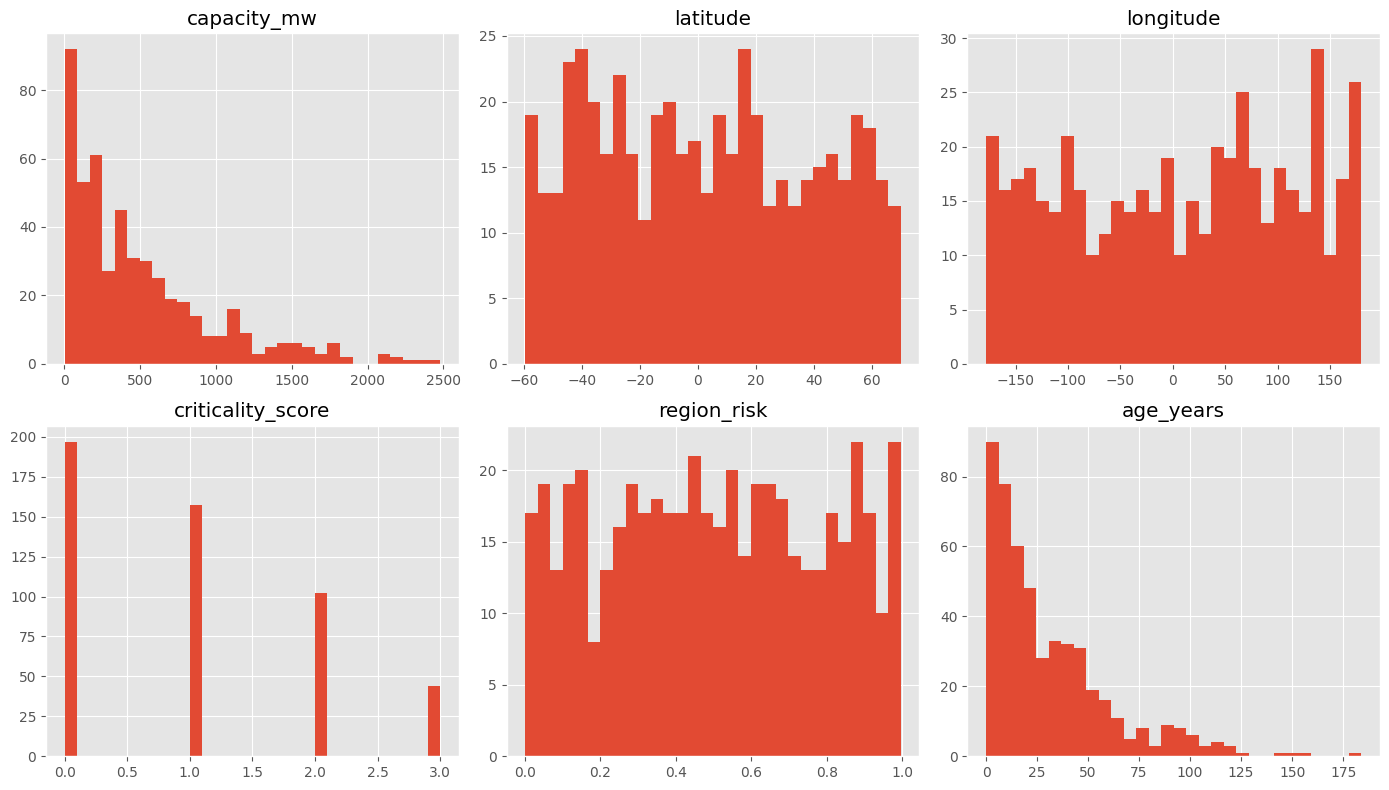

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i, col in enumerate(df.select_dtypes(include=np.number).columns[:6]):
    ax = axes[i // 3, i % 3]
    df[col].hist(bins=30, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig('../artifacts/01_eda_histograms.png', dpi=100)
plt.show()

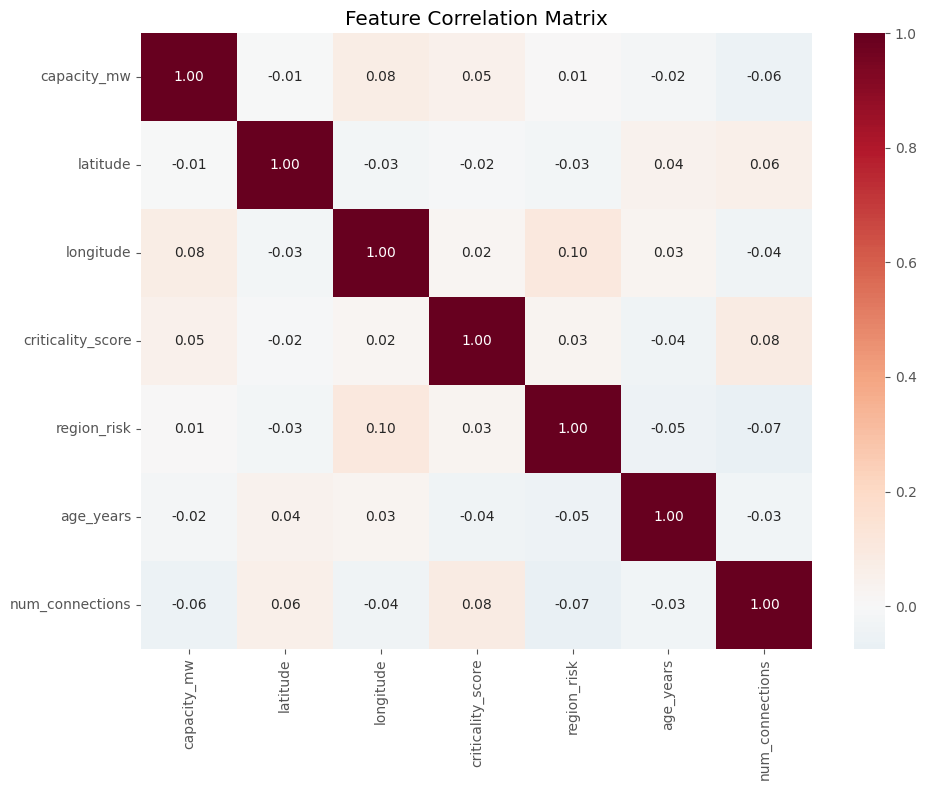

In [5]:
corr = df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('../artifacts/01_eda_correlation.png', dpi=100)
plt.show()

In [6]:
# Missing values
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False) if missing.any() else print("No missing values")

No missing values


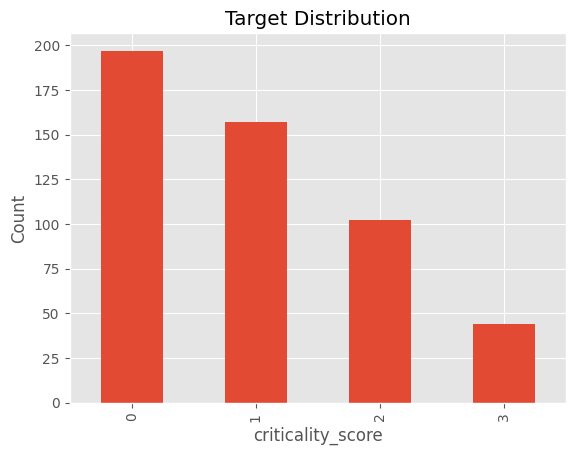

In [7]:
# Target distribution
if 'criticality_score' in df.columns:
    df['criticality_score'].value_counts().sort_index().plot(kind='bar', title='Target Distribution')
    plt.ylabel('Count')
    plt.savefig('../artifacts/01_eda_target.png', dpi=100)
    plt.show()

In [8]:
import pandas as pd

df = pd.read_parquet("../datasets/geopolitical_risk_v1/geopolitical_risk_v1.parquet")

df.head()

,country,year,week,total_events,goldstein_mean,goldstein_std,goldstein_min,goldstein_max,goldstein_neg_count,goldstein_pos_count,...,total_mentions_lag1,total_mentions_lag4,total_mentions_rolling4_mean,total_mentions_change_wow,avg_tone_lag1,avg_tone_lag4,avg_tone_rolling4_mean,avg_tone_change_wow,week_sin,week_cos
0,ABW,2023,2,2,0.000000,0.000000,0.0,0.0,0,0,...,NaN,NaN,8.000000,NaN,NaN,NaN,-0.498753,NaN,0.239316,0.970942
1,ABW,2023,11,4,2.350000,0.519615,1.9,2.8,0,0,...,8.0,NaN,24.000000,32.0,-0.498753,NaN,-0.653534,-0.309561,0.970942,0.239316
2,ABW,2024,1,82,1.712195,1.961631,-5.0,4.0,0,0,...,40.0,NaN,177.333333,444.0,-0.808314,NaN,0.806691,4.535456,0.120537,0.992709
3,ABW,2024,2,102,1.749020,4.030840,-9.5,8.0,8,14,...,484.0,NaN,311.000000,228.0,3.727142,NaN,1.076788,-1.840064,0.239316,0.970942
4,ABW,2024,3,58,-0.437500,2.020604,-10.0,8.0,4,4,...,712.0,8.0,368.500000,-474.0,1.887078,-0.498753,1.260312,-1.651734,0.354605,0.935016


In [9]:
df.info()
df.describe().T
df["risk_flag"].value_counts()
df.isna().sum().sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5953 entries, 0 to 5952
Data columns (total 74 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   country                                           5953 non-null   object 
 1   year                                              5953 non-null   UInt32 
 2   week                                              5953 non-null   UInt32 
 3   total_events                                      5953 non-null   int64  
 4   goldstein_mean                                    5953 non-null   float64
 5   goldstein_std                                     5953 non-null   float64
 6   goldstein_min                                     5953 non-null   float64
 7   goldstein_max                                     5953 non-null   float64
 8   goldstein_neg_count                               5953 non-null   int64  
 9   goldstein_pos_count

energy_2026_fuel_super_petrol                       5953
energy_2025_fuel_petrol_gasoline_95_octane          5953
energy_2026_fuel_petrol_gasoline_95_octane          5953
energy_2025_fuel_super_petrol                       5939
energy_2026_fuel_petrol_gasoline_parallel_market    5925
                                                    ... 
unique_actors1                                         0
unique_actors2                                         0
sanction_count                                         0
port_count                                             0
week_cos                                               0
Length: 74, dtype: int64

In [10]:
# 1
df["risk_flag"].value_counts(normalize=True)
# 2
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct.head(30)# 3
df.columns.tolist()

['country',
 'year',
 'week',
 'total_events',
 'goldstein_mean',
 'goldstein_std',
 'goldstein_min',
 'goldstein_max',
 'goldstein_neg_count',
 'goldstein_pos_count',
 'quadclass_verbal_conflict',
 'quadclass_material_conflict',
 'total_mentions',
 'total_sources',
 'total_articles',
 'avg_tone',
 'unique_actors1',
 'unique_actors2',
 'sanction_count',
 'port_count',
 'energy_2025_fuel_diesel',
 'energy_2025_fuel_gas',
 'energy_2025_fuel_kerosene',
 'energy_2025_fuel_petrol_gasoline',
 'energy_2025_fuel_petrol_gasoline_95_octane',
 'energy_2025_fuel_petrol_gasoline_parallel_market',
 'energy_2025_fuel_super_petrol',
 'energy_2026_fuel_diesel',
 'energy_2026_fuel_gas',
 'energy_2026_fuel_kerosene',
 'energy_2026_fuel_petrol_gasoline',
 'energy_2026_fuel_petrol_gasoline_95_octane',
 'energy_2026_fuel_petrol_gasoline_parallel_market',
 'energy_2026_fuel_super_petrol',
 'GEM-GGIT-Gas-Pipelin_Pipelines',
 'GEM-GOIT-Oil-NGL-Pip_Data',
 'Global-Coal-Mine-Tra_Historical Prod',
 'Global-Coal-P

## Key Takeaways
- Check distributions --  skewed features may need transformation
- Check correlations --  highly correlated features may be redundant
- Check class balance --  imbalanced targets need stratified splitting or weighting
- Document all findings for production feature engineering